In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\5_comp
scenario=5comp_equal  K_MODEL=5  K_TRUE=5
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth, Grids (Full + Chebyshev) & Trimmed Mass ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's pooled-marginal mean +/- 5*std (exact moments via
#                 the law of total variance), so >= 96% of each model's marginal
#                 mass is guaranteed inside for any distribution.
# Trimmed-mass tables report the realised trim EXACTLY (mixture CDF, no grid
# error) - equal to the renormalisation each density receives in Cell 5. The
# window is symmetric in x, not in mass: the left/right split shows the skew.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

for label, grids in GRIDS.items():
    trimmed = {m["name"]: (1.0 - mc.retained_mass(m, grids)) * 100.0
               for m in models + [true_model]}
    print(f"\nMass trimmed by the [{label}] window, in % of each marginal:")
    display(pd.DataFrame(trimmed, index=param_names).T.round(4))

cheb = GRIDS["Chebyshev (k=5, >=96%)"]
split = {}
for m in models + [true_model]:
    l, r = mc.trimmed_tails(m, cheb)
    split[m["name"]] = np.r_[l, r] * 100.0
cols = pd.MultiIndex.from_product([["left tail", "right tail"], param_names])
print("\nChebyshev trim by side, in % of each marginal:")
display(pd.DataFrame(split, index=cols).T.round(4))

Grid extents [Full]:
  Alt1       [-398.57, +525.52]
  Alt2       [-206.46, +237.52]
  Alt3       [-151.73, +146.85]
  Price      [-155.79, +133.95]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-8.93, +13.74]
  Alt2       [-13.43, +15.94]
  Alt3       [-15.89, +17.18]
  Price      [-22.04, +19.76]

Mass trimmed by the [Full] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0,0.0,0.0,0.0
HMC,0.0,0.0,0.0,0.0
NUTS,0.0,0.0,0.0,0.0
replication,0.0,0.0,0.0,0.0
True DGP,0.0,0.0,0.0,0.0



Mass trimmed by the [Chebyshev (k=5, >=96%)] window, in % of each marginal:


,Alt1,Alt2,Alt3,Price
bayesm,0.0000,0.0000,0.0000,0.0000
HMC,0.0339,0.0176,0.0123,0.0032
NUTS,0.0018,0.0010,0.0011,0.0001
replication,0.0000,0.0001,0.0000,0.0000
True DGP,0.0000,0.0000,0.0000,0.0000



Chebyshev trim by side, in % of each marginal:


left tail                         right tail                  \
                 Alt1    Alt2    Alt3   Price       Alt1    Alt2    Alt3   
bayesm         0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   
HMC            0.0167  0.0083  0.0082  0.0017     0.0172  0.0093  0.0041   
NUTS           0.0011  0.0004  0.0008  0.0000     0.0007  0.0006  0.0003   
replication    0.0000  0.0001  0.0000  0.0000     0.0000  0.0000  0.0000   
True DGP       0.0000  0.0000  0.0000  0.0000     0.0000  0.0000  0.0000   

                     
              Price  
bayesm       0.0000  
HMC          0.0015  
NUTS         0.0001  
replication  0.0000  
True DGP     0.0000

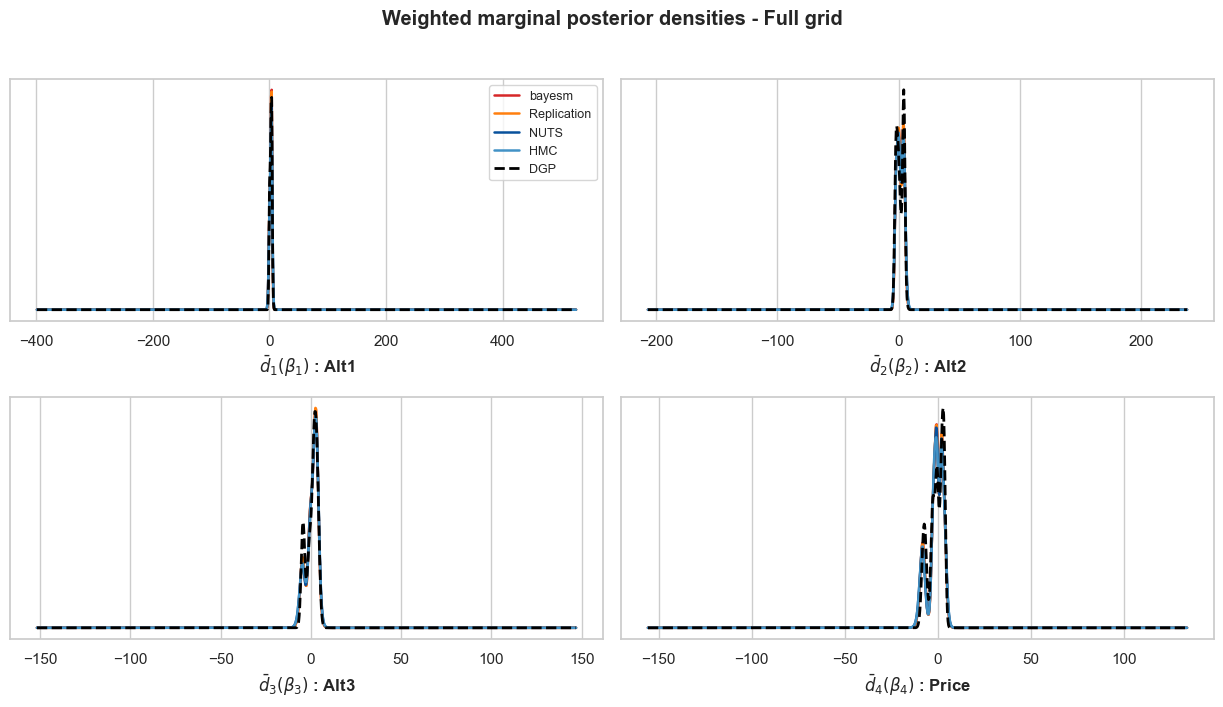

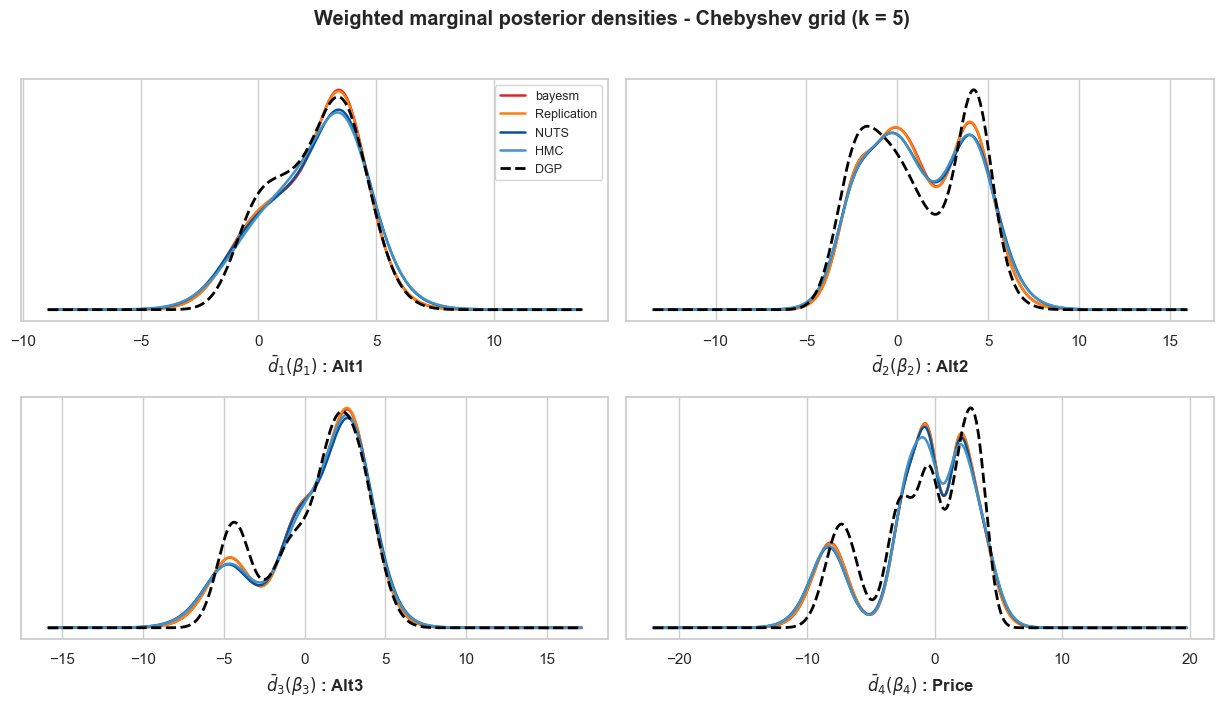

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass. Legend order: bayesm, Replication, NUTS, HMC, DGP.
# DGP dashed black, bayesm red, Replication orange, NUTS/HMC in blues.
# Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728", "replication": "#ff7f0e"}
TRUE_COLOR = "#000000"
LEGEND_ORDER = ["bayesm", "replication", "NUTS", "HMC"]
DISPLAY_NAME = {"NUTS": "NUTS", "HMC": "HMC", "bayesm": "bayesm", "replication": "Replication"}
TITLE_SUFFIX = {"Full": "Full grid", "Chebyshev (k=5, >=96%)": "Chebyshev grid (k = 5)"}
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.6), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name in LEGEND_ORDER:
            if name not in dens:
                continue
            ax[j].plot(grids[j], dens[name][j], lw=1.8, label=DISPLAY_NAME[name],
                       color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="DGP")
        ax[j].set_xlabel(rf"$\bar{{d}}_{{{j+1}}}(\beta_{{{j+1}}})$ : {pj}", fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Weighted marginal posterior densities - {TITLE_SUFFIX.get(label, label)}",
                 fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): KL(model||true)
# and TVD. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:258: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


KL      TVD
sampler     param                  
bayesm      Alt1   0.02593  0.04015
            Alt2   0.02071  0.08552
            Alt3   0.05169  0.06430
            Price  0.10232  0.14162
HMC         Alt1       inf  0.06248
            Alt2       inf  0.09236
            Alt3       inf  0.06828
            Price      inf  0.15114
NUTS        Alt1   0.05240  0.06342
            Alt2       inf  0.09133
            Alt3       inf  0.07969
            Price      inf  0.14768
replication Alt1   0.02555  0.03790
            Alt2   0.02043  0.08468
            Alt3   0.04960  0.06308
            Price  0.10288  0.14136

--- Chebyshev (k=5, >=96%) ---


KL      TVD
sampler     param                  
bayesm      Alt1   0.02593  0.04202
            Alt2   0.02071  0.08560
            Alt3   0.05167  0.06425
            Price  0.10232  0.14133
HMC         Alt1   0.06384  0.06247
            Alt2   0.03700  0.09304
            Alt3   0.08938  0.06820
            Price  0.14290  0.15160
NUTS        Alt1   0.05071  0.06440
            Alt2   0.03184  0.09208
            Alt3   0.08944  0.07995
            Price  0.13527  0.14769
replication Alt1   0.02554  0.03988
            Alt2   0.02039  0.08468
            Alt3   0.04958  0.06299
            Price  0.10287  0.14113

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.346,2.402,2.396,2.349,2.388
Alt2,1.318,1.333,1.346,1.318,1.142
Alt3,0.634,0.644,0.649,0.641,0.560
Price,-1.127,-1.139,-1.149,-1.129,-1.000


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,4.162,5.113000,4.666000,4.164000,3.603
Alt2,7.811,8.500000,8.374000,7.832000,8.496
Alt3,10.200,10.890000,10.858000,10.159000,9.511
Price,16.632,17.403999,17.311001,16.641001,15.138


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 430s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.001   1456.528   4935.142       3.391      11.490
      sd          1.000   1291.873   3665.929       3.008       8.535
      q05         1.001   4102.066  10650.739       9.551      24.798
      q50         1.001   1222.189   4686.999       2.846      10.913
      q95         1.002    710.858   1923.120       1.655       4.478
Alt2  mean        1.000   3141.413   8710.198       7.314      20.280
      sd          1.001    953.270   2343.996       2.219       5.458
      q05         1.002    701.291   2185.615       1.633       5.089
      q50         1.000   3010.020   7358.450       7.008      17.133
      q95         1.001    886.070   2601.802       2.063       6.058
Alt3  mean        1.000   1903.334   4694.609       4.432      10.930
      sd          1.001    574.883   1002.337       1.338       2.334
      q05         1.002    453.218    781.709       1.055       1.820
      q50         1.001   4069.881   9457.188       9.476      22.019
      q95         1.000   1200.060   3097.051       2.794       7.211
Price mean        1.002   1767.435   6309.499       4.115      14.690
      sd          1.008    399.454    756.378       0.930       1.761
      q05         1.014    234.115    432.470       0.545       1.007
      q50         1.000  16371.508  18274.592      38.118      42.549
      q95         1.004    797.279   1807.648       1.856       4.209

--- HMC  (fit wall-clock: 478s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.004   460.806  1071.032       0.965       2.243
      sd          1.035    54.849    85.207       0.115       0.178
      q05         1.005  1451.080  5423.339       3.039      11.358
      q50         1.031    62.226  1907.278       0.130       3.994
      q95         1.029    95.358  1137.142       0.200       2.381
Alt2  mean        1.004  1058.016  4145.170       2.216       8.681
      sd          1.034    57.192   235.623       0.120       0.493
      q05         1.002   219.748   537.111       0.460       1.125
      q50         1.012   381.677  3795.274       0.799       7.948
      q95         1.008   543.941  1459.022       1.139       3.056
Alt3  mean        1.003   519.688  1282.555       1.088       2.686
      sd          1.007   219.766  1459.679       0.460       3.057
      q05         1.001   256.176   515.010       0.536       1.079
      q50         1.014   993.849  2911.966       2.081       6.098
      q95         1.010   406.718  1676.850       0.852       3.512
Price mean        1.001   914.614  4329.893       1.915       9.068
      sd          1.003   265.129  1296.700       0.555       2.716
      q05         1.002   168.355   880.349       0.353       1.844
      q50         1.053    24.741   810.700       0.052       1.698
      q95         1.025   234.489  1382.693       0.491       2.896

--- NUTS  (fit wall-clock: 1,171s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.001   3101.209   7316.422       2.648       6.247
      sd          1.002   2093.772   4932.549       1.788       4.212
      q05         1.000   6312.891  12656.423       5.390      10.806
      q50         1.002   2916.645   6973.033       2.490       5.954
      q95         1.003   1500.574   4146.400       1.281       3.540
Alt2  mean        1.000   5801.793  10987.016       4.954       9.381
      sd          1.002   1856.053   4823.851       1.585       4.119
      q05         1.002   2090.193   4448.521       1.785       3.798
      q50         1.000   4967.948   9835.229       4.242       8.398
      q95         1.002   2019.835   4281.456       1.725       3.656
Alt3  mean        1.000   4162.708   7751.592       3.554       6.619
      sd          1.001   2079.536   4030.201       1.776       3.441
      q05         1.001   1643.908   3128.723       1.404       2.671
      q50         1.000   6422.821  11682.118       5.484       9.974
      q95         1.001   1884.158   3548.431       1.609       3.030
Price mean        1.000   5569.753  10109.694       4.756       8.632
      sd          1.002   1416.727   2990.409       1.210       2.553
      q05         1.001    958.103   2026.469       0.818       1.730
      q50         1.000  13362.464  14399.950      11.409      12.295
      q95         1.002   2616.702   6060.961       2.234       5.175

--- replication  (fit wall-clock: 367s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.002   1363.130   4966.846       3.710      13.519
      sd          1.001   1044.000   4368.745       2.842      11.891
      q05         1.001   4358.231   9475.523      11.862      25.791
      q50         1.003   1088.034   4904.691       2.961      13.350
      q95         1.000    571.829   1692.756       1.556       4.607
Alt2  mean        1.002   2735.456   9409.652       7.445      25.611
      sd          1.003    991.874   2971.365       2.700       8.088
      q05         1.006    567.108   1646.619       1.544       4.482
      q50         1.003   1967.685   6578.403       5.356      17.905
      q95         1.004    952.827   2592.398       2.593       7.056
Alt3  mean        1.001   1868.548   4849.552       5.086      13.200
      sd          1.003    658.004   1539.631       1.791       4.191
      q05         1.002    463.859   1001.440       1.263       2.726
      q50         1.000   4354.515  10888.430      11.852      29.636
      q95         1.004   1086.536   2740.375       2.957       7.459
Price mean        1.002   1767.050   7571.561       4.810      20.608
      sd          1.010    273.539   1042.505       0.745       2.838
      q05         1.016    159.045    528.913       0.433       1.440
      q50         1.000  14382.474  16289.321      39.147      44.337
      q95         1.002    781.027   1815.390       2.126       4.941

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
